In [27]:
import random
from pathlib import Path

import torch
import torch.nn as nn
import pandas as pd 
import numpy as np

from ware_ops_algos.data_loaders import HesslerIrnichLoader
from ware_ops_algos.domain_models import BaseWarehouseDomain

from ware_ops_sim.rl.models.matnet import ATSP_Encoder

In [3]:
def find_project_root() -> Path:
    """Find project root by looking for a marker file."""
    current = Path().resolve()
    for parent in [current] + list(current.parents):
        if (parent / "pyproject.toml").exists():  # or setup.py, .git, etc.
            return parent
    raise FileNotFoundError("Could not find project root")


def get_distance(source, target, dist_array, node_to_idx) -> float:
    """Fast distance lookup."""
    return dist_array[node_to_idx[source], node_to_idx[target]]


class HesslerIrnichRunner:
    def __init__(self, instance_set_name: str, instances_dir: Path, cache_dir: Path,
                 project_root: Path):
        self.instance_set_name = instance_set_name
        self.instances_dir = instances_dir
        self.cache_dir = cache_dir
        self.project_root = project_root
        self.loader = HesslerIrnichLoader(str(instances_dir), str(cache_dir))

    def discover_instances(self) -> list[tuple[str, list[Path]]]:
        instances = []
        for filepath in self.instances_dir.glob("*.txt"):
            if filepath.is_file():
                instances.append((filepath.stem, [filepath]))
        return instances

    def load_domain(self, file_paths: list[Path]) -> BaseWarehouseDomain:
        return self.loader.load(file_paths[0].name, use_cache=True)

In [54]:
from ware_ops_algos.domain_models import Order


def encode_order(order: Order, domain: BaseWarehouseDomain) -> np.ndarray:
    article_location_mapping = domain.storage.article_location_mapping
    
    if hasattr(order, "order_positions"):
        positions = order.order_positions
    else:
        positions = order.pick_positions

    n_positions = len(positions)
    total_amount = sum(p.amount for p in positions)

    locations = [article_location_mapping[p.article_id][0] for p in positions]  # TODO FIX DUPLICATE ENTRIES
    aisles = [loc.x for loc in locations]
    positions_y = [loc.y for loc in locations]

    centroid_x = np.mean(aisles)
    centroid_y = np.mean(positions_y)
    aisle_span = max(aisles) - min(aisles)
    position_span = max(positions_y) - min(positions_y)
    n_unique_aisles = len(set(aisles))
    
    # time_until_due = order.due_date - current_time

    return np.array([
        n_positions,
        total_amount,
        centroid_x,
        centroid_y,
        aisle_span,
        position_span,
        n_unique_aisles,
    ], dtype=np.float32)

In [11]:
PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"

instances_base = DATA_DIR / "instances"
cache_base = DATA_DIR / "instances" / "caches"
order_list_online = instances_base / "" / "instances_100_1.txt"

loader_online = HesslerIrnichLoader(
    instances_dir=DATA_DIR / "SPRP",
    cache_dir=DATA_DIR / "caches" / "KrisLargeData",
)

results_sprp = pd.read_csv(DATA_DIR / "results/results_SPRP.csv", sep=";", decimal=",", thousands=".")


results_sprp["filename"] = results_sprp.apply(
    lambda
        row: f"unit_F1_m{row['num aisles']}_C{row['num cells']}_a{row['num articles']}_{row['random seed']}",
    axis=1
)
results_sprp.rename(columns={"GS MIP cost": "LB"}, inplace=True)

runner = HesslerIrnichRunner(instance_set_name="SPRP",
                             instances_dir=DATA_DIR / "instances" / "SPRP",
                             cache_dir=DATA_DIR / "instances" / "caches" / "SPRP",
                             project_root=PROJECT_ROOT)

instances = runner.discover_instances()

In [34]:
samples = []
hc_samples = []
# assume: samples = list of (coords_tensor, dist_tensor, cost) tuples
# coords: (1, n_items, 2), dist: (1, n_items, n_items), cost: float
n_instance = len(instances)
i = 0
for instance in instances:
    if i % 100 == 0:
        print(f"{i} / {n_instance}")
    domain = runner.load_domain(instance[1])
    storage_locations = domain.storage    
    layout = domain.layout
    layout_network = layout.layout_network
    depot = layout_network.closest_node_to_start
    depot_x, depot_y = depot
    dist_mat_array = layout_network.distance_matrix.values
    node_to_idx = {node: idx for idx, node in enumerate(layout_network.distance_matrix.index)}
    assert len(domain.orders.orders) == 1
    order = domain.orders.orders[0]
    features = encode_order(order, domain)
    # for coords, dist, cost in samples
    # order = next(o for o in orders.orders if len(o.order_positions) > 1)
    locs = [storage_locations.article_location_mapping[p.article_id][0] for p in order.order_positions]
    # nodes = [(loc.x, loc.y) for loc in locs]
    nodes = [depot] + [(loc.x, loc.y) for loc in locs]
    # --- build coords tensor ---
    # coords = torch.tensor([[loc.x, loc.y] for loc in locs], dtype=torch.float32)
    coords = torch.tensor([[depot_x, depot_y]] + [[loc.x, loc.y] for loc in locs], dtype=torch.float32)
    # shape: (n_items, 2)
    
    # --- build dist matrix from your existing lookup ---
    n = len(nodes)
    dist = torch.zeros(n, n)
    for i in range(n):
        for j in range(n):
            dist[i, j] = get_distance(nodes[i], nodes[j], dist_mat_array, node_to_idx)
    # shape: (n_items, n_items)
    
    # --- add batch dim ---
    coords = coords.unsqueeze(0)  # (1, n_items, 2)
    dist = dist.unsqueeze(0)
    
    cost = results_sprp[results_sprp["filename"] == instance[0]]["DP cost"].item()

    samples.append((coords, dist, cost))
    hc_samples.append((features, cost))

    i += 1

0 / 2400


KeyboardInterrupt: 

In [35]:
len(samples)

756

In [36]:
costs = [cost for _, _, cost in samples]
print(f"min: {min(costs):.0f}, max: {max(costs):.0f}, mean: {sum(costs)/len(costs):.0f}")

min: 48, max: 2808, mean: 663


In [38]:
costs = [cost for _, _, cost in samples]
mean_cost = np.mean(costs)
std_cost = np.std(costs)

samples_norm = [(coords, dist, (cost - mean_cost) / std_cost) for coords, dist, cost in samples]
hc_samples_norm = [(features, (cost - mean_cost) / std_cost) for features, cost in hc_samples]

In [29]:
random.shuffle(samples_norm)
split = int(len(samples_norm) * 0.8)
train_samples = samples_norm[:split]
val_samples = samples_norm[split:]

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
# assume: samples = list of (coords_tensor, dist_tensor, cost) tuples
# coords: (1, n_items, 2), dist: (1, n_items, n_items), cost: float

device = torch.device('cpu')
torch.set_default_tensor_type('torch.FloatTensor')

model_params = {
    'embedding_dim': 64,
    'sqrt_embedding_dim': 64 ** 0.5,
    'encoder_layer_num': 3,
    'qkv_dim': 16,
    'sqrt_qkv_dim': 16 ** 0.5,
    'head_num': 4,
    'ff_hidden_dim': 128,
    'ms_hidden_dim': 16,
    'ms_layer1_init': (1/2) ** 0.5,
    'ms_layer2_init': (1/4) ** 0.5,
}

input_proj = nn.Linear(2, 64)
encoder = ATSP_Encoder(**model_params)
head = nn.Linear(64, 1)

params = list(input_proj.parameters()) + list(encoder.parameters()) + list(head.parameters())
optimizer = Adam(params, lr=1e-4)
for epoch in range(100):
    random.shuffle(train_samples)
    # train
    total_loss = 0
    for coords, dist, cost in train_samples:
        optimizer.zero_grad()
        emb = input_proj(coords)
        encoded_row, _ = encoder(emb, emb, dist)
        pooled = encoded_row.mean(dim=1)
        predicted = head(pooled).squeeze()
        target = torch.tensor(cost, dtype=torch.float32)
        loss = F.mse_loss(predicted, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # val
    with torch.no_grad():
        val_loss = 0
        for coords, dist, cost in val_samples:
            emb = input_proj(coords)
            encoded_row, _ = encoder(emb, emb, dist)
            pooled = encoded_row.mean(dim=1)
            predicted = head(pooled).squeeze()
            target = torch.tensor(cost, dtype=torch.float32)
            val_loss += F.mse_loss(predicted, target).item()

    if epoch % 2 == 0:
        print(f"epoch {epoch} | train loss {total_loss / len(train_samples):.4f} | val loss {val_loss / len(val_samples):.4f}")

epoch 0 | train loss 0.4749 | val loss 0.2972
epoch 2 | train loss 0.1868 | val loss 0.2136
epoch 4 | train loss 0.1271 | val loss 0.1491
epoch 6 | train loss 0.0929 | val loss 0.2196
epoch 8 | train loss 0.1167 | val loss 0.1360
epoch 10 | train loss 0.0993 | val loss 0.1551
epoch 12 | train loss 0.0709 | val loss 0.1086
epoch 14 | train loss 0.0735 | val loss 0.1232
epoch 16 | train loss 0.0789 | val loss 0.1042
epoch 18 | train loss 0.0726 | val loss 0.0850
epoch 20 | train loss 0.0646 | val loss 0.1389
epoch 22 | train loss 0.0540 | val loss 0.1074
epoch 24 | train loss 0.0533 | val loss 0.0654
epoch 26 | train loss 0.0484 | val loss 0.0781
epoch 28 | train loss 0.0482 | val loss 0.0661
epoch 30 | train loss 0.0471 | val loss 0.0704
epoch 32 | train loss 0.0467 | val loss 0.0654
epoch 34 | train loss 0.0349 | val loss 0.0708
epoch 36 | train loss 0.0389 | val loss 0.0583
epoch 38 | train loss 0.0358 | val loss 0.1476
epoch 40 | train loss 0.0365 | val loss 0.0808
epoch 42 | train l

R²: 0.970


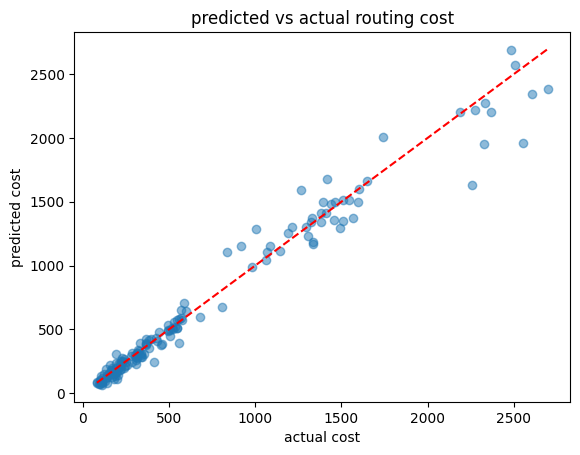

In [32]:
preds, actuals = [], []
with torch.no_grad():
    for coords, dist, cost in val_samples:
        emb = input_proj(coords)
        encoded_row, _ = encoder(emb, emb, dist)
        pooled = encoded_row.mean(dim=1)
        predicted = head(pooled).squeeze().item()
        preds.append(predicted * std_cost + mean_cost)
        actuals.append(cost * std_cost + mean_cost)

# R²
ss_res = sum((a - p) ** 2 for a, p in zip(actuals, preds))
ss_tot = sum((a - np.mean(actuals)) ** 2 for a in actuals)
print(f"R²: {1 - ss_res/ss_tot:.3f}")

import matplotlib.pyplot as plt
plt.scatter(actuals, preds, alpha=0.5)
plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--')
plt.xlabel("actual cost")
plt.ylabel("predicted cost")
plt.title("predicted vs actual routing cost")
plt.show()

#  Feature Engineering

In [39]:
random.shuffle(hc_samples_norm)
split = int(len(hc_samples_norm) * 0.8)
hc_train = hc_samples_norm[:split]
hc_val = hc_samples_norm[split:]

# baseline model: 7 features -> 1 output
hc_head = nn.Sequential(
    nn.Linear(7, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)
hc_optimizer = Adam(hc_head.parameters(), lr=1e-4)

for epoch in range(100):
    random.shuffle(hc_train)
    total_loss = 0
    for features, cost in hc_train:
        hc_optimizer.zero_grad()
        x = torch.tensor(features, dtype=torch.float32).unsqueeze(0)
        predicted = hc_head(x).squeeze()
        target = torch.tensor(cost, dtype=torch.float32)
        loss = F.mse_loss(predicted, target)
        loss.backward()
        hc_optimizer.step()
        total_loss += loss.item()

    if epoch % 10 == 0:
        with torch.no_grad():
            preds, actuals = [], []
            for features, cost in hc_val:
                x = torch.tensor(features, dtype=torch.float32).unsqueeze(0)
                predicted = hc_head(x).squeeze().item()
                preds.append(predicted * std_cost + mean_cost)
                actuals.append(cost * std_cost + mean_cost)
            ss_res = sum((a - p) ** 2 for a, p in zip(actuals, preds))
            ss_tot = sum((a - np.mean(actuals)) ** 2 for a in actuals)
            r2 = 1 - ss_res / ss_tot
        print(f"epoch {epoch} | train loss {total_loss / len(hc_train):.4f} | val R² {r2:.3f}")

epoch 0 | train loss 5.2528 | val R² -1.044
epoch 10 | train loss 0.2312 | val R² 0.802
epoch 20 | train loss 0.1349 | val R² 0.852
epoch 30 | train loss 0.0943 | val R² 0.929
epoch 40 | train loss 0.0709 | val R² 0.949
epoch 50 | train loss 0.0578 | val R² 0.939
epoch 60 | train loss 0.0663 | val R² 0.958
epoch 70 | train loss 0.0594 | val R² 0.960
epoch 80 | train loss 0.0485 | val R² 0.931
epoch 90 | train loss 0.0506 | val R² 0.963


# Batching Evaluation

In [42]:
runner = HesslerIrnichRunner(instance_set_name="MuterOencan",
                             instances_dir=DATA_DIR / "instances" / "MuterOencan",
                             cache_dir=DATA_DIR / "instances" / "caches" / "MuterOencan",
                             project_root=PROJECT_ROOT)

muteroencan_instances = runner.discover_instances()

In [45]:
from itertools import combinations
from ware_ops_algos.algorithms import ClarkAndWrightBatching, NearestNeighbourhoodRouting, BatchObject, \
    GreedyItemAssignment

pair_samples = []

for instance in muteroencan_instances:
    domain = runner.load_domain(instance[1])
    storage_locations = domain.storage
    orders = domain.orders
    
    selector = GreedyItemAssignment(storage_locations)
    ia_sol = selector.solve(orders.orders)
    orders = ia_sol.resolved_orders
    if len(orders) < 2:
        continue
    
    layout = domain.layout
    layout_network = layout.layout_network
    articles = domain.articles
    resources = domain.resources
    
    routing_kwargs = {
        "start_node": layout_network.start_node,
        "end_node": layout_network.end_node,
        "closest_node_to_start": layout_network.closest_node_to_start,
        "min_aisle_position": layout_network.min_aisle_position,
        "max_aisle_position": layout_network.max_aisle_position,
        "distance_matrix": layout_network.distance_matrix,
        "predecessor_matrix": layout_network.predecessor_matrix,
        "picker": resources.resources,
        "gen_tour": False,
        "gen_item_sequence": False,
    }
    
    batcher = ClarkAndWrightBatching(
        pick_cart=resources.resources[0].pick_cart,
        articles=articles,
        routing_class=NearestNeighbourhoodRouting,
        routing_class_kwargs=routing_kwargs,
    )
    
    order_pairs = list(combinations(orders, 2))
    random.shuffle(order_pairs)
    order_pairs = order_pairs[:200]  # cap per domain to avoid imbalance
    
    for order_a, order_b in order_pairs:
        batch_a = BatchObject(batch_id=0, orders=[order_a])
        batch_b = BatchObject(batch_id=1, orders=[order_b])
        savings = batcher._calculate_saving(batch_a, batch_b)
        pair_samples.append((order_a, order_b, savings, domain))
    
    print(f"loaded {instance[0]}: {len(orders)} orders, {len(order_pairs)} pairs, total {len(pair_samples)}")

print(f"done: {len(pair_samples)} pairs total")

loaded 100_24_0: 100 orders, 200 pairs, total 200
loaded 100_24_1: 100 orders, 200 pairs, total 400
loaded 100_24_2: 100 orders, 200 pairs, total 600
loaded 100_24_3: 100 orders, 200 pairs, total 800
loaded 100_24_4: 100 orders, 200 pairs, total 1000
loaded 100_24_5: 100 orders, 200 pairs, total 1200
loaded 100_24_6: 100 orders, 200 pairs, total 1400
loaded 100_24_7: 100 orders, 200 pairs, total 1600
loaded 100_24_8: 100 orders, 200 pairs, total 1800
loaded 100_24_9: 100 orders, 200 pairs, total 2000
loaded 100_36_0: 100 orders, 200 pairs, total 2200
loaded 100_36_1: 100 orders, 200 pairs, total 2400
loaded 100_36_2: 100 orders, 200 pairs, total 2600
loaded 100_36_3: 100 orders, 200 pairs, total 2800
loaded 100_36_4: 100 orders, 200 pairs, total 3000
loaded 100_36_5: 100 orders, 200 pairs, total 3200
loaded 100_36_6: 100 orders, 200 pairs, total 3400
loaded 100_36_7: 100 orders, 200 pairs, total 3600
loaded 100_36_8: 100 orders, 200 pairs, total 3800
loaded 100_36_9: 100 orders, 200 pa

In [47]:
def build_order_tensors(order, domain):
    storage_locations = domain.storage
    layout_network = domain.layout.layout_network
    depot = layout_network.closest_node_to_start
    depot_x, depot_y = depot
    dist_mat_array = layout_network.distance_matrix.values
    node_to_idx = {node: idx for idx, node in enumerate(layout_network.distance_matrix.index)}

    locs = [storage_locations.article_location_mapping[p.article_id][0] for p in order.pick_positions]
    nodes = [depot] + [(loc.x, loc.y) for loc in locs]

    coords = torch.tensor([[depot_x, depot_y]] + [[loc.x, loc.y] for loc in locs], dtype=torch.float32)
    n = len(nodes)
    dist = torch.zeros(n, n)
    for i in range(n):
        for j in range(n):
            dist[i, j] = get_distance(nodes[i], nodes[j], dist_mat_array, node_to_idx)

    return coords.unsqueeze(0), dist.unsqueeze(0)


tensor_samples = []
for i, (order_a, order_b, savings, domain) in enumerate(pair_samples):
    if i % 5000 == 0:
        print(f"{i} / {len(pair_samples)}")
    coords_a, dist_a = build_order_tensors(order_a, domain)
    coords_b, dist_b = build_order_tensors(order_b, domain)
    tensor_samples.append((coords_a, dist_a, coords_b, dist_b, savings))

0 / 53700
5000 / 53700
10000 / 53700
15000 / 53700
20000 / 53700
25000 / 53700
30000 / 53700
35000 / 53700
40000 / 53700
45000 / 53700
50000 / 53700


In [49]:
savings_values = [s for _, _, _, _, s in tensor_samples]
mean_savings = np.mean(savings_values)
std_savings = np.std(savings_values)

print(f"min: {min(savings_values):.0f}, max: {max(savings_values):.0f}, mean: {mean_savings:.0f}, std: {std_savings:.0f}")
print(f"positive savings: {sum(1 for s in savings_values if s > 0)} / {len(savings_values)}")

tensor_samples_norm = [(ca, da, cb, db, (s - mean_savings) / std_savings) 
                       for ca, da, cb, db, s in tensor_samples]

random.shuffle(tensor_samples_norm)
split = int(len(tensor_samples_norm) * 0.8)
train_pairs = tensor_samples_norm[:split]
val_pairs = tensor_samples_norm[split:]

print(f"train: {len(train_pairs)}, val: {len(val_pairs)}")

min: -11, max: 118, mean: 50, std: 17
positive savings: 53659 / 53700
train: 42960, val: 10740


In [55]:
# collect HC pair samples
hc_pair_samples = []
for order_a, order_b, savings, domain in pair_samples:
    feat_a = encode_order(order_a, domain)
    feat_b = encode_order(order_b, domain)
    hc_pair_samples.append((feat_a, feat_b, savings))

# normalize savings same way
hc_pair_norm = [(fa, fb, (s - mean_savings) / std_savings) for fa, fb, s in hc_pair_samples]
random.shuffle(hc_pair_norm)
split = int(len(hc_pair_norm) * 0.8)
hc_train = hc_pair_norm[:split]
hc_val = hc_pair_norm[split:]

# model: 7+7=14 input features
hc_predictor = nn.Sequential(
    nn.Linear(14, 64),
    nn.ReLU(),
    nn.Linear(64, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
)
hc_optimizer = Adam(hc_predictor.parameters(), lr=1e-4)

for epoch in range(100):
    random.shuffle(hc_train)
    total_loss = 0
    for feat_a, feat_b, savings in hc_train:
        hc_optimizer.zero_grad()
        x = torch.tensor(np.concatenate([feat_a, feat_b]), dtype=torch.float32).unsqueeze(0)
        predicted = hc_predictor(x).squeeze()
        target = torch.tensor(savings, dtype=torch.float32)
        loss = F.mse_loss(predicted, target)
        loss.backward()
        hc_optimizer.step()
        total_loss += loss.item()

    if epoch % 2 == 0:
        with torch.no_grad():
            preds, actuals = [], []
            for feat_a, feat_b, savings in hc_val:
                x = torch.tensor(np.concatenate([feat_a, feat_b]), dtype=torch.float32).unsqueeze(0)
                predicted = hc_predictor(x).squeeze().item()
                preds.append(predicted * std_savings + mean_savings)
                actuals.append(savings * std_savings + mean_savings)
            ss_res = sum((a - p) ** 2 for a, p in zip(actuals, preds))
            ss_tot = sum((a - np.mean(actuals)) ** 2 for a in actuals)
            r2 = 1 - ss_res / ss_tot
        print(f"epoch {epoch} | train loss {total_loss / len(hc_train):.4f} | val R² {r2:.3f}")

epoch 0 | train loss 0.4299 | val R² 0.648
epoch 2 | train loss 0.3426 | val R² 0.677
epoch 4 | train loss 0.3250 | val R² 0.692
epoch 6 | train loss 0.3178 | val R² 0.678
epoch 8 | train loss 0.3141 | val R² 0.684
epoch 10 | train loss 0.3103 | val R² 0.703
epoch 12 | train loss 0.3082 | val R² 0.675
epoch 14 | train loss 0.3056 | val R² 0.685
epoch 16 | train loss 0.3039 | val R² 0.696
epoch 18 | train loss 0.3030 | val R² 0.689
epoch 20 | train loss 0.3018 | val R² 0.703
epoch 22 | train loss 0.3005 | val R² 0.705
epoch 24 | train loss 0.2993 | val R² 0.694
epoch 26 | train loss 0.2981 | val R² 0.702
epoch 28 | train loss 0.2961 | val R² 0.694
epoch 30 | train loss 0.2953 | val R² 0.706
epoch 32 | train loss 0.2944 | val R² 0.705
epoch 34 | train loss 0.2930 | val R² 0.705
epoch 36 | train loss 0.2924 | val R² 0.671
epoch 38 | train loss 0.2910 | val R² 0.697


KeyboardInterrupt: 

In [56]:
class SavingsPredictor(nn.Module):
    def __init__(self, embedding_dim=64):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(embedding_dim * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, emb_a, emb_b):
        x = torch.cat([emb_a, emb_b, emb_a - emb_b, emb_a * emb_b], dim=-1)
        return self.head(x).squeeze()


input_proj = nn.Linear(2, 64)
encoder = ATSP_Encoder(**model_params)
predictor = SavingsPredictor(embedding_dim=64)

params = list(input_proj.parameters()) + list(encoder.parameters()) + list(predictor.parameters())
optimizer = Adam(params, lr=1e-4)


def encode_order_matnet(coords, dist):
    emb = input_proj(coords)
    encoded_row, _ = encoder(emb, emb, dist)
    return encoded_row.mean(dim=1)  # (1, 64)


for epoch in range(100):
    random.shuffle(train_pairs)
    total_loss = 0
    for coords_a, dist_a, coords_b, dist_b, savings in train_pairs:
        optimizer.zero_grad()
        emb_a = encode_order_matnet(coords_a, dist_a)
        emb_b = encode_order_matnet(coords_b, dist_b)
        predicted = predictor(emb_a, emb_b)
        target = torch.tensor(savings, dtype=torch.float32)
        loss = F.mse_loss(predicted, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 10 == 0:
        with torch.no_grad():
            preds, actuals = [], []
            for coords_a, dist_a, coords_b, dist_b, savings in val_pairs:
                emb_a = encode_order_matnet(coords_a, dist_a)
                emb_b = encode_order_matnet(coords_b, dist_b)
                predicted = predictor(emb_a, emb_b).item()
                preds.append(predicted * std_savings + mean_savings)
                actuals.append(savings * std_savings + mean_savings)
            ss_res = sum((a - p) ** 2 for a, p in zip(actuals, preds))
            ss_tot = sum((a - np.mean(actuals)) ** 2 for a in actuals)
            r2 = 1 - ss_res / ss_tot
        print(f"epoch {epoch} | train loss {total_loss / len(train_pairs):.4f} | val R² {r2:.3f}")

epoch 0 | train loss 0.3305 | val R² 0.702


KeyboardInterrupt: 

In [57]:
from collections import defaultdict

# group tensor_samples_norm by (n_items_a, n_items_b)
size_groups = defaultdict(list)
for coords_a, dist_a, coords_b, dist_b, savings in tensor_samples_norm:
    key = (coords_a.shape[1], coords_b.shape[1])
    size_groups[key].append((coords_a, dist_a, coords_b, dist_b, savings))

print(f"number of size groups: {len(size_groups)}")
print(f"largest group: {max(len(v) for v in size_groups.values())}")
print(f"smallest group: {min(len(v) for v in size_groups.values())}")

number of size groups: 98
largest group: 889
smallest group: 4


In [59]:
def make_batches(group, batch_size=32):
    batches = []
    for i in range(0, len(group), batch_size):
        chunk = group[i:i+batch_size]
        coords_a = torch.cat([x[0] for x in chunk], dim=0)
        dist_a   = torch.cat([x[1] for x in chunk], dim=0)
        coords_b = torch.cat([x[2] for x in chunk], dim=0)
        dist_b   = torch.cat([x[3] for x in chunk], dim=0)
        savings  = torch.tensor([x[4] for x in chunk], dtype=torch.float32)
        batches.append((coords_a, dist_a, coords_b, dist_b, savings))
    return batches

In [60]:
# build batched groups
batch_size = 32
all_batches = []
for key, group in size_groups.items():
    all_batches.extend(make_batches(group, batch_size=batch_size))

print(f"total batches: {len(all_batches)}")

# train/val split on batches
random.shuffle(all_batches)
split = int(len(all_batches) * 0.8)
train_batches = all_batches[:split]
val_batches = all_batches[split:]

# reinitialize model
input_proj = nn.Linear(2, 64)
encoder = ATSP_Encoder(**model_params)
predictor = SavingsPredictor(embedding_dim=64)
params = list(input_proj.parameters()) + list(encoder.parameters()) + list(predictor.parameters())
optimizer = Adam(params, lr=1e-4)

for epoch in range(100):
    random.shuffle(train_batches)
    total_loss = 0
    for coords_a, dist_a, coords_b, dist_b, savings in train_batches:
        optimizer.zero_grad()
        emb_a = encode_order_matnet(coords_a, dist_a)
        emb_b = encode_order_matnet(coords_b, dist_b)
        predicted = predictor(emb_a, emb_b)
        loss = F.mse_loss(predicted, savings)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 2 == 0:
        with torch.no_grad():
            preds, actuals = [], []
            for coords_a, dist_a, coords_b, dist_b, savings in val_batches:
                emb_a = encode_order_matnet(coords_a, dist_a)
                emb_b = encode_order_matnet(coords_b, dist_b)
                predicted = predictor(emb_a, emb_b)
                preds.extend(predicted.tolist())
                actuals.extend(savings.tolist())
            preds_denorm = [p * std_savings + mean_savings for p in preds]
            actuals_denorm = [a * std_savings + mean_savings for a in actuals]
            ss_res = sum((a - p) ** 2 for a, p in zip(actuals_denorm, preds_denorm))
            ss_tot = sum((a - np.mean(actuals_denorm)) ** 2 for a in actuals_denorm)
            r2 = 1 - ss_res / ss_tot
        print(f"epoch {epoch} | train loss {total_loss / len(train_batches):.4f} | val R² {r2:.3f}")

total batches: 1729


C:\Users\zm0714\AppData\Local\Temp\ipykernel_19648\802113386.py:30: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(predicted, savings)


TypeError: 'float' object is not iterable